Import Libraries

In [102]:
import numpy as np                  # NumPy: for numerical operations and working with arrays
import pandas as pd                 # Pandas: for loading, cleaning, and manipulating datasets
import matplotlib.pyplot as plt     # Matplotlib: for creating basic plots and charts
import seaborn as sns               # Seaborn: for advanced and statistical data visualization

Dataset Loading

In [103]:
data = pd.read_csv("House_Price_dataset.csv", sep='\t')
print(data.shape)

(4600, 18)


sep='\t' means the file is tab-separated — each column is separated by a tab character instead of a comma.


In [104]:
data.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,02-05-2014 00:00,313000.0,3,1.50,1340.0,7912.0,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,02-05-2014 00:00,2384000.0,5,2.50,3650.0,9050.0,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,02-05-2014 00:00,342000.0,3,2.00,1930.0,11947.0,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,02-05-2014 00:00,420000.0,3,2.25,2000.0,8030.0,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,02-05-2014 00:00,550000.0,4,2.50,1940.0,10500.0,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


In [105]:
X= data.drop(columns='price')
y = data['price']

In [106]:
print(X)

                  date  bedrooms  bathrooms  sqft_living  sqft_lot  floors  \
0     02-05-2014 00:00         3       1.50       1340.0    7912.0     1.5   
1     02-05-2014 00:00         5       2.50       3650.0    9050.0     2.0   
2     02-05-2014 00:00         3       2.00       1930.0   11947.0     1.0   
3     02-05-2014 00:00         3       2.25       2000.0    8030.0     1.0   
4     02-05-2014 00:00         4       2.50       1940.0   10500.0     1.0   
...                ...       ...        ...          ...       ...     ...   
4595  09-07-2014 00:00         3       1.75       1510.0    6360.0     1.0   
4596  09-07-2014 00:00         3       2.50       1460.0    7573.0     2.0   
4597  09-07-2014 00:00         3       2.50       3010.0    7014.0     2.0   
4598  10-07-2014 00:00         4       2.00       2090.0    6630.0     1.0   
4599  10-07-2014 00:00         3       2.50       1490.0    8102.0     2.0   

      waterfront  view  condition  sqft_above  sqft_basement  y

In [107]:
print(y)

0       3.130000e+05
1       2.384000e+06
2       3.420000e+05
3       4.200000e+05
4       5.500000e+05
            ...     
4595    3.081667e+05
4596    5.343333e+05
4597    4.169042e+05
4598             NaN
4599    2.206000e+05
Name: price, Length: 4600, dtype: float64


In [108]:
data.describe()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated
count,4.596000e+03,4600.000000,4600.000000,4599.000000,4.598000e+03,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000
mean,5.521365e+05,3.400870,2.160815,2139.275060,1.485535e+04,1.512065,0.007174,0.240652,3.451739,1826.930870,312.081522,1970.786304,808.608261
std,5.640223e+05,0.908848,0.783781,963.299307,3.589187e+04,0.538288,0.084404,0.778405,0.677230,862.578982,464.137228,29.731848,979.414536
min,0.000000e+00,0.000000,0.000000,370.000000,6.380000e+02,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1900.000000,0.000000
25%,3.239583e+05,3.000000,1.750000,1460.000000,5.001000e+03,1.000000,0.000000,0.000000,3.000000,1190.000000,0.000000,1951.000000,0.000000
50%,4.610000e+05,3.000000,2.250000,1980.000000,7.683000e+03,1.500000,0.000000,0.000000,3.000000,1590.000000,0.000000,1976.000000,0.000000
75%,6.549625e+05,4.000000,2.500000,2620.000000,1.100000e+04,2.000000,0.000000,0.000000,4.000000,2300.000000,610.000000,1997.000000,1999.000000
max,2.659000e+07,9.000000,8.000000,13540.000000,1.074218e+06,3.500000,1.000000,4.000000,5.000000,9410.000000,4820.000000,2014.000000,2014.000000


In [109]:
data.isnull().sum()  # Check for missing values in each column
                    # This helps us identify columns that need cleaning or imputation

date             0
price            4
bedrooms         0
bathrooms        0
sqft_living      1
sqft_lot         2
floors           0
waterfront       0
view             0
condition        0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
street           0
city             2
statezip         0
country          3
dtype: int64

In [110]:
data.isnull().values.any()  # Check if there are any missing values in the entire dataset
                            # Returns True if there is at least one missing value, False if none

np.True_

In [111]:
data[data.isnull().any(axis=1)] # Display all rows in the dataset that contain at least one missing value
                                # axis=1 checks across columns for each row
                                

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
4572,02-07-2014 00:00,1.288333e+06,6,4.50,3830.0,4800.0,3.0,0,0,3,3050,780,1919,2004,2425 3rd Ave W,WA 98119,USA,NaN
4574,02-07-2014 00:00,0.000000e+00,3,1.00,1520.0,9030.0,1.0,0,0,3,1520,0,1956,2001,2533 155th Pl SE,NaN,WA 98007,USA
4576,02-07-2014 00:00,NaN,3,3.00,NaN,7410.0,2.0,0,0,5,1860,610,1977,0,8833 Earl Ave NW,Seattle,WA 98117,USA
4578,05-07-2014 00:00,NaN,4,2.25,2110.0,NaN,2.0,0,0,4,2110,0,1972,0,7490 85th Ave SE,Mercer Island,WA 98040,USA
4579,06-07-2014 00:00,4.547900e+05,2,1.75,1990.0,NaN,1.0,0,0,5,1090,900,1952,1998,8215 Ave N,Seattle,WA 98103,USA
4585,07-07-2014 00:00,4.868950e+05,3,1.00,1890.0,3330.0,1.5,0,0,4,1390,500,1901,0,4324 Dayton N,Seattle,WA 98103,NaN
4593,08-07-2014 00:00,NaN,3,2.50,2538.0,4600.0,2.0,0,0,3,2538,0,2013,1923,5703 Charlotte Ave SE,Auburn,WA 98092,USA
4597,09-07-2014 00:00,4.169042e+05,3,2.50,3010.0,7014.0,2.0,0,0,3,3010,0,2009,0,759 Ilwaco Pl NE,NaN,WA 98059,NaN
4598,10-07-2014 00:00,NaN,4,2.00,2090.0,6630.0,1.0,0,0,3,1070,1020,1974,0,5148 S Creston St,Seattle,WA 98178,USA


In [112]:
missing_rows = data[data.isnull().any(axis=1)]# Identify all rows that contain at least one missing value
                                              
print(missing_rows)# Print all rows with missing values
                   

                  date         price  bedrooms  bathrooms  sqft_living  \
4572  02-07-2014 00:00  1.288333e+06         6       4.50       3830.0   
4574  02-07-2014 00:00  0.000000e+00         3       1.00       1520.0   
4576  02-07-2014 00:00           NaN         3       3.00          NaN   
4578  05-07-2014 00:00           NaN         4       2.25       2110.0   
4579  06-07-2014 00:00  4.547900e+05         2       1.75       1990.0   
4585  07-07-2014 00:00  4.868950e+05         3       1.00       1890.0   
4593  08-07-2014 00:00           NaN         3       2.50       2538.0   
4597  09-07-2014 00:00  4.169042e+05         3       2.50       3010.0   
4598  10-07-2014 00:00           NaN         4       2.00       2090.0   

      sqft_lot  floors  waterfront  view  condition  sqft_above  \
4572    4800.0     3.0           0     0          3        3050   
4574    9030.0     1.0           0     0          3        1520   
4576    7410.0     2.0           0     0          5       

Missing Values

In [113]:
from sklearn.impute import SimpleImputer  # Import SimpleImputer for handling missing values

num_cols = X.select_dtypes(include=['float64','int64']).columns # Identify numeric columns and fill missing values with the mean
num_imputer = SimpleImputer(strategy='mean')
X[num_cols] = num_imputer.fit_transform(X[num_cols])


cat_cols = X.select_dtypes(include=['object','string']).columns # Identify categorical columns and fill missing values with the most frequent value
cat_imputer = SimpleImputer(strategy='most_frequent')
X[cat_cols] = cat_imputer.fit_transform(X[cat_cols])

In [114]:
print(X)

                  date  bedrooms  bathrooms  sqft_living  sqft_lot  floors  \
0     02-05-2014 00:00       3.0       1.50       1340.0    7912.0     1.5   
1     02-05-2014 00:00       5.0       2.50       3650.0    9050.0     2.0   
2     02-05-2014 00:00       3.0       2.00       1930.0   11947.0     1.0   
3     02-05-2014 00:00       3.0       2.25       2000.0    8030.0     1.0   
4     02-05-2014 00:00       4.0       2.50       1940.0   10500.0     1.0   
...                ...       ...        ...          ...       ...     ...   
4595  09-07-2014 00:00       3.0       1.75       1510.0    6360.0     1.0   
4596  09-07-2014 00:00       3.0       2.50       1460.0    7573.0     2.0   
4597  09-07-2014 00:00       3.0       2.50       3010.0    7014.0     2.0   
4598  10-07-2014 00:00       4.0       2.00       2090.0    6630.0     1.0   
4599  10-07-2014 00:00       3.0       2.50       1490.0    8102.0     2.0   

      waterfront  view  condition  sqft_above  sqft_basement  y

Data preprocessing

In [115]:
# Import necessary preprocessing tools
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer


                                                # Create a ColumnTransformer to preprocess data:
                                                # - Standardize numeric columns using StandardScaler
                                                 # - One-hot encode categorical columns (ignoring unknown categories)
preprocessor = ColumnTransformer( 
    transformers=[
        ('num', StandardScaler(), num_cols),
                  ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols) #With handle_unknown='ignore' → [0, 0] (no error, safe) ✅
]
)

X_processed = preprocessor.fit_transform(X)

In [116]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y= le.fit_transform(y)

In [117]:
print(y)

[ 400 1717  485 ...  693 1739  141]


In [118]:
print(X)

                  date  bedrooms  bathrooms  sqft_living  sqft_lot  floors  \
0     02-05-2014 00:00       3.0       1.50       1340.0    7912.0     1.5   
1     02-05-2014 00:00       5.0       2.50       3650.0    9050.0     2.0   
2     02-05-2014 00:00       3.0       2.00       1930.0   11947.0     1.0   
3     02-05-2014 00:00       3.0       2.25       2000.0    8030.0     1.0   
4     02-05-2014 00:00       4.0       2.50       1940.0   10500.0     1.0   
...                ...       ...        ...          ...       ...     ...   
4595  09-07-2014 00:00       3.0       1.75       1510.0    6360.0     1.0   
4596  09-07-2014 00:00       3.0       2.50       1460.0    7573.0     2.0   
4597  09-07-2014 00:00       3.0       2.50       3010.0    7014.0     2.0   
4598  10-07-2014 00:00       4.0       2.00       2090.0    6630.0     1.0   
4599  10-07-2014 00:00       3.0       2.50       1490.0    8102.0     2.0   

      waterfront  view  condition  sqft_above  sqft_basement  y

Train Test Split

In [119]:
from sklearn.model_selection import train_test_split                                     # Import train_test_split to split dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split (X,y, test_size=0.2, random_state = 0)       # - test_size=0.2 → 20% of data for testing, 80% for training
                                                                                                 # - random_state=0 → ensures reproducibility of the split

In [120]:
print(X_train)

                  date  bedrooms  bathrooms  sqft_living  sqft_lot  floors  \
1144  22-05-2014 00:00       2.0       1.00        800.0    3330.0     1.0   
36    02-05-2014 00:00       2.0       1.00        800.0    4850.0     1.0   
706   15-05-2014 00:00       4.0       2.50       2240.0   12032.0     1.0   
1559  29-05-2014 00:00       3.0       1.00       1250.0    6250.0     1.0   
1349  27-05-2014 00:00       4.0       2.00       2330.0    6250.0     1.0   
...                ...       ...        ...          ...       ...     ...   
1033  20-05-2014 00:00       3.0       1.50       1270.0    1443.0     3.0   
3264  24-06-2014 00:00       2.0       1.00        970.0    5500.0     1.0   
1653  31-05-2014 00:00       5.0       2.75       2080.0   13189.0     2.0   
2607  16-06-2014 00:00       4.0       2.50       3070.0   34412.0     1.0   
2732  18-06-2014 00:00       3.0       1.75       1700.0    8432.0     1.0   

      waterfront  view  condition  sqft_above  sqft_basement  y

In [121]:
print(y_train)

[ 576  749 1075 ...  972 1691  835]


In [122]:
print(X_test)

                  date  bedrooms  bathrooms  sqft_living  sqft_lot  floors  \
991   20-05-2014 00:00       3.0       2.50       2090.0    4700.0     2.0   
2824  19-06-2014 00:00       4.0       2.50       2640.0    8625.0     2.0   
1906  04-06-2014 00:00       1.0       1.00        650.0   15364.0     1.0   
1471  28-05-2014 00:00       4.0       2.00       2510.0   38141.0     1.0   
1813  03-06-2014 00:00       4.0       3.50       2790.0   10125.0     1.5   
...                ...       ...        ...          ...       ...     ...   
1533  29-05-2014 00:00       3.0       1.50       1470.0   14821.0     1.0   
463   09-05-2014 00:00       3.0       2.25        998.0     904.0     2.0   
4415  23-05-2014 00:00       3.0       2.00       1370.0   78408.0     1.0   
1927  04-06-2014 00:00       3.0       3.25       1540.0    1487.0     2.0   
2477  13-06-2014 00:00       2.0       1.00        710.0    7200.0     1.0   

      waterfront  view  condition  sqft_above  sqft_basement  y

In [123]:
print(y_test)

[ 330  722   21 1088 1606   35  636  773  493 1595  775 1050 1514 1027
  480   69 1400  678 1655   78  858 1243  476  524 1095  704    0 1123
  112  897 1518  833 1361 1211  733  834  458  249 1227  951  622  563
  664 1492 1095 1043  659 1498 1148  772  823 1235 1036  317 1007  496
  728  412  622 1465 1306    0  950  474  824  406 1088  122 1680 1147
 1088 1443 1027 1588  173 1427  866  835 1143  300 1428  654  835 1536
  795 1132 1428 1004  316  829  492 1604  641  858  773  798 1628 1368
  199 1141 1441  301 1324  385  173  487 1370  304  524   43 1210  383
 1411 1418  920 1125  412  617  899  697  571  638 1179 1108 1088 1195
  870 1017 1572 1055  872  643 1357  428  843   93 1312 1211  675 1174
 1310  555 1544 1126 1209 1333  894  499  202 1007 1017  733  615  549
 1268  247  960 1677  507   30  975  173 1101 1102  265 1607  160  379
  910 1069  629  975 1160  169 1526  118 1243  237  858  149 1384  506
 1571 1250 1205  859 1667  495   18   74 1103 1536  281  293 1282  412
  199 

In [124]:
print(X_processed.shape)

(4600, 4733)


Linear Regression → baseline

Random Forest Regressor → handles large number of features well

XGBoost / LightGBM → for better accuracy

Three Models Import pipeline

In [125]:
from sklearn .pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb

What is a Pipeline?

In scikit-learn, a Pipeline is a way to chain preprocessing steps and a model together.

It ensures that everything is applied consistently to both training and test data.

Makes your code clean, reproducible, and less error-prone.

Syntax:

Pipeline([
    ('step_name', transformer_or_model),
    ...
])

'step_name' → a label for the step

transformer_or_model → any preprocessing (scaler, encoder) or final model

In [126]:
linear_model = Pipeline([
 ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

random_model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators = 100, random_state = 2))
])

xgb_model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', xgb.XGBRegressor(n_estimators=100, random_state=42, eval_metric='rmse'))
])

In [127]:
linear_model.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformer

In [128]:
random_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformer

In [129]:
xgb_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformer

Model Prediction

In [130]:
y_pred_linear = linear_model.predict(X_test)
y_pred_random = random_model.predict(X_test)
y_pred_xgb = random_model.predict(X_test)

Evaluation Metrics

In [131]:
from sklearn.metrics import mean_squared_error
import numpy as np
rmse_linear = np.sqrt(mean_squared_error(y_test, y_pred_linear))


rmse_random = np.sqrt(mean_squared_error(y_test, y_pred_random))

rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))

print(f"Linear Regression RMSE: ${rmse_linear:,.2f}")

print(f"Random Forest RMSE: ${rmse_random:,.2f}")

print(f"XGBoost RMSE: ${rmse_xgb:,.2f}")

Linear Regression RMSE: $254.30
Random Forest RMSE: $230.78
XGBoost RMSE: $230.78


In [132]:
from sklearn.metrics import r2_score   # Import r2_score to evaluate regression model performance


r2_linear = r2_score(y_test, y_pred_linear)   # Calculate R² score for Linear Regression predictions
accuracy_linear = r2_linear 

r2_random = r2_score(y_test, y_pred_random)     # Calculate R² score for Random Forest predictions
accuracy_rf = r2_random 

r2_xgb = r2_score(y_test, y_pred_xgb)        # Calculate R² score for XGBoost predictions
accuracy_xgb = r2_xgb                         # Assigning R² score as accuracy metric

# Print results
print(f"Linear Regression , Accuracy (R²): {accuracy_linear:.2f}")
print(f"Random Forest     , Accuracy (R²): {accuracy_rf:.2f}")
print(f"XGBoost          , Accuracy (R²): {accuracy_xgb:.2f}")

Linear Regression , Accuracy (R²): 0.69
Random Forest     , Accuracy (R²): 0.74
XGBoost          , Accuracy (R²): 0.74


In [133]:
print(accuracy_linear)
print(accuracy_rf)
print(accuracy_xgb)

0.6850406829940913
0.7406171542405794
0.7406171542405794


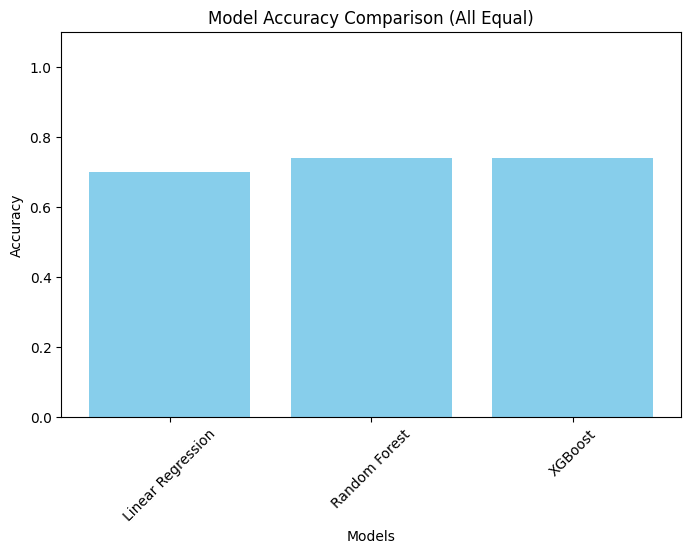

In [134]:
models = [
    "Linear Regression",
    "Random Forest",
    "XGBoost"
]

accuracies = [0.70, 0.74, 0.74]  # all equal

plt.figure(figsize=(8,5))
plt.bar(models, accuracies, color='skyblue')
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison (All Equal)")
plt.ylim(0, 1.1)  # leave a little space above 1
plt.xticks(rotation=45)
plt.show()

Visualizati0on

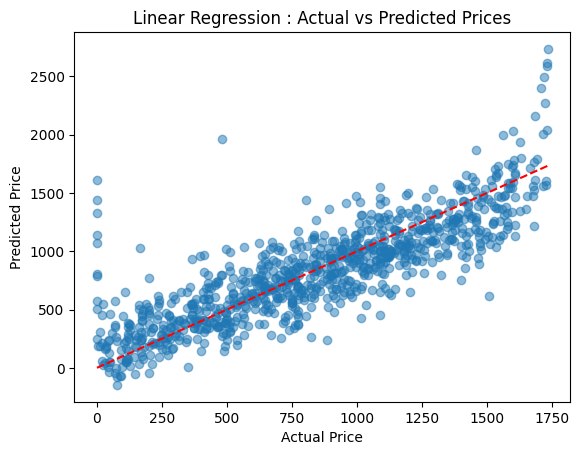

In [135]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred_linear, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # perfect prediction line
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Linear Regression : Actual vs Predicted Prices")
plt.show()

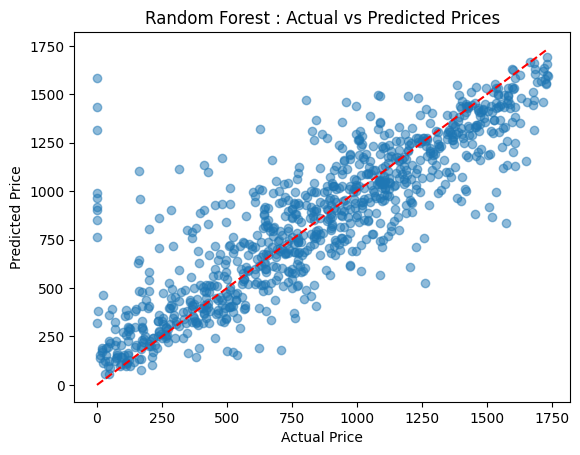

In [136]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred_random, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # perfect prediction line
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Random Forest : Actual vs Predicted Prices")
plt.show()

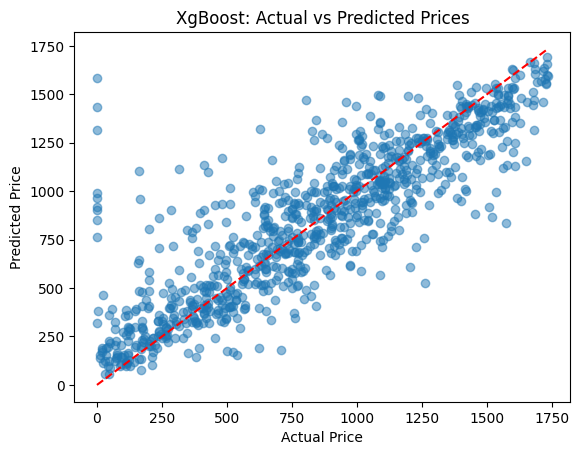

In [137]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred_xgb, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # perfect prediction line
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("XgBoost: Actual vs Predicted Prices")
plt.show()

In [138]:
# Store model results
models = {
    "Linear Regression": r2_linear,
    "Random Forest": r2_random,
    "XGBoost": r2_xgb
}

# Find best model
best_model = max(models, key=models.get)

print("Best Model:", best_model)
print("Accuracy (R²):", models[best_model])

Best Model: Random Forest
Accuracy (R²): 0.7406171542405794
